# Sim2 Image Perturbations Report

A narrative overview of the Sim2 cropped dataset and the synthetic perturbations used throughout the Monte Carlo Dropout study.

### Environment setup

Run the following cell once per new kernel to install dependencies locally.

In [ ]:
%pip install -r ../requirements.txt
%pip install -e ..

In [1]:

import sys
from pathlib import Path
from typing import Callable, List
import numpy as np
import pandas as pd
import pickle
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance
from PIL import Image

plt.rcParams.update({"figure.figsize": (8, 4), "axes.grid": True})

TRANSFORM_CATEGORY_COLORS = {
    'reference': '#7f7f7f',
    'gaussian_noise': '#1f77b4',
    'salt_pepper': '#2ca02c',
    'downsample_bicubic': '#ff7f0e',
    'downsample_pixel': '#9467bd',
}

PAINT_COLOR_MAP = {
    'indigo': '#6a5acd',  # purple
    'magenta': '#ff69b4',  # pink
    'yellow': '#ffd54f',  # yellow
    'wolf': '#d62728',  # red
    'moose': '#8b4513',  # brown
    'white': '#bcb8b1',  # gray
}

def paint_color_hex(name: str, default: str = '#7f7f7f') -> str:
    'Return a display hex for the given Jeep colour name.'
    key = name.lower()
    for token, hex_code in PAINT_COLOR_MAP.items():
        if key.startswith(token):
            return hex_code
    return default

NOTEBOOK_ROOT = Path.cwd()
REPO_ROOT = NOTEBOOK_ROOT if (NOTEBOOK_ROOT / 'src').exists() else NOTEBOOK_ROOT.parent
SRC_ROOT = REPO_ROOT / 'src'
for path in (SRC_ROOT, REPO_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

print(f"Repository root: {REPO_ROOT}")


Repository root: /home/fwromano/Documents/Code/UCLIP


In [2]:

DATA_ROOT = REPO_ROOT / 'data/car_sim/sim2_cropped_45deg'
if not DATA_ROOT.exists():
    raise FileNotFoundError(f'Missing dataset at {DATA_ROOT}')

image_paths = sorted(DATA_ROOT.glob('*/*.png'))
print(f"Found {len(image_paths)} images across {len({p.parent.name for p in image_paths})} colors.")


Found 46 images across 6 colors.


In [3]:
def _parse_angle(path: Path) -> int:
    token = path.stem.split('_')[-1]
    try:
        return int(token)
    except ValueError:
        return -1

records = []
for path in image_paths:
    color = path.parent.name
    if color.lower().startswith('moose'):
        continue
    records.append({
        'image_id': f"{color}_{path.stem.split('_')[-1]}",
        'path': path,
        'color': color,
        'angle': _parse_angle(path)
    })

dataset_df = pd.DataFrame(records).sort_values(['color', 'angle']).reset_index(drop=True)
color_counts = dataset_df.groupby('color')['image_id'].count().rename('count')

### Dataset snapshot

Each color contributes eight viewpoints (every 45°).

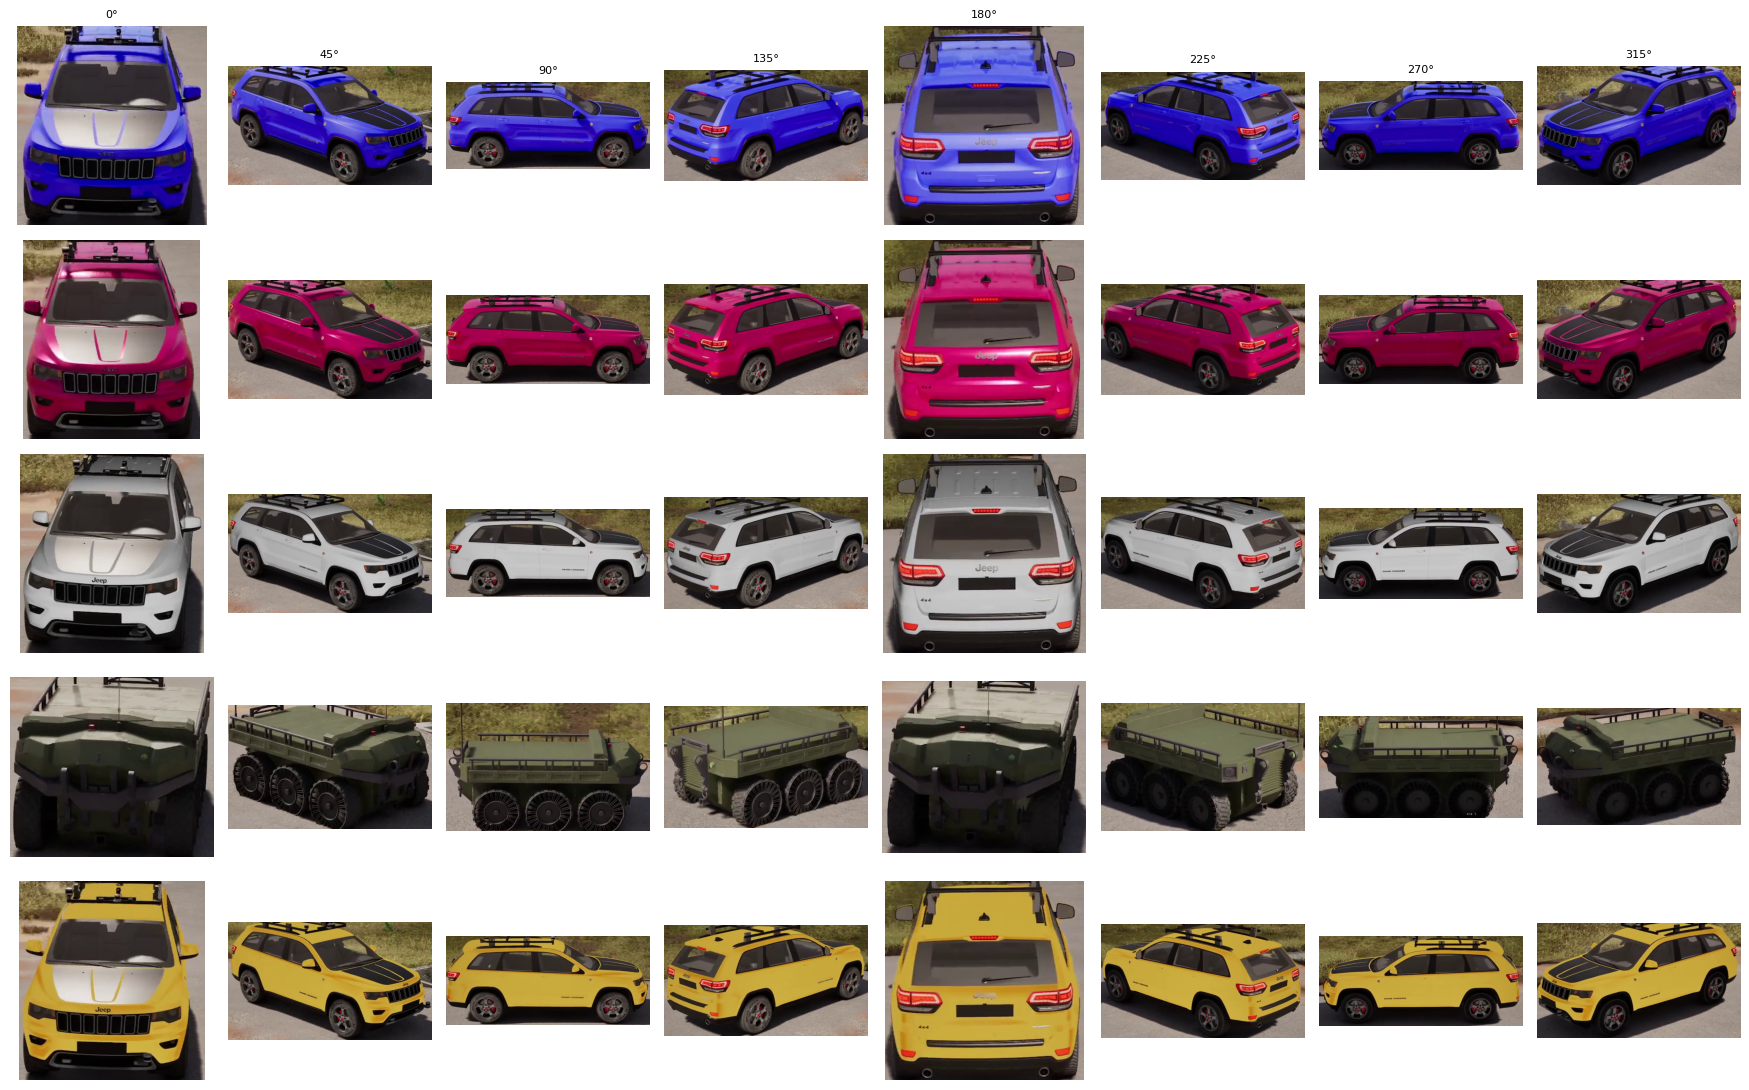

In [4]:
angles = sorted(dataset_df['angle'].unique())
colors = sorted(dataset_df['color'].unique())

fig, axes = plt.subplots(len(colors), len(angles), figsize=(2.2 * len(angles), 2.2 * len(colors)))
if len(colors) == 1:
    axes = axes[None, :]
if len(angles) == 1:
    axes = axes[:, None]

for row, color in enumerate(colors):
    for col, angle in enumerate(angles):
        ax = axes[row, col]
        row_match = dataset_df[(dataset_df['color'] == color) & (dataset_df['angle'] == angle)]
        if not row_match.empty:
            with Image.open(row_match.iloc[0]['path']) as img:
                ax.imshow(img.convert('RGB'))
        ax.axis('off')
        if row == 0:
            ax.set_title(f"{angle}°", fontsize=8)
        if col == 0:
            ax.set_ylabel(color, fontsize=8, rotation=0, labelpad=24, ha='right', va='center')

plt.tight_layout()
plt.show()

*Full gallery of the 46 cropped renderings (Moose variants omitted) grouped by color (rows) and camera angle (columns).*

In [5]:
TARGET_COLOR = 'Indigo'
TARGET_ANGLE = 0
base_path = DATA_ROOT / TARGET_COLOR / f'{TARGET_COLOR}_{TARGET_ANGLE:03d}.png'
with Image.open(base_path) as img:
    base_image = img.convert('RGB')

### Selected perturbations

We inspect a subset of noise and resolution degradations applied to the same frame.

In [6]:

TransformFn = Callable[[Image.Image], Image.Image]

def gaussian_noise_transform(std: float, seed: int) -> TransformFn:
    rng = np.random.default_rng(seed)
    def apply(image: Image.Image) -> Image.Image:
        arr = np.asarray(image).astype(np.float32) / 255.0
        noise = rng.normal(0.0, std, size=arr.shape)
        noisy = np.clip(arr + noise, 0.0, 1.0)
        return Image.fromarray((noisy * 255).round().astype(np.uint8))
    return apply

def salt_pepper_transform(amount: float, seed: int) -> TransformFn:
    rng = np.random.default_rng(seed)
    def apply(image: Image.Image) -> Image.Image:
        arr = np.asarray(image).copy()
        h, w, _ = arr.shape
        n = int(amount * h * w)
        idx = rng.choice(h * w, size=n, replace=False)
        salt = idx[: n // 2]
        pepper = idx[n // 2:]
        arr[np.unravel_index(salt, (h, w))] = 255
        arr[np.unravel_index(pepper, (h, w))] = 0
        return Image.fromarray(arr)
    return apply

def downsample_transform(percent: int, resample=Image.BICUBIC) -> TransformFn:
    scale = max(1.0 - percent / 100.0, 1e-4)
    def apply(image: Image.Image) -> Image.Image:
        w, h = image.size
        target = (max(1, int(round(w * scale))), max(1, int(round(h * scale))))
        lowres = image.resize(target, resample=resample)
        return lowres.resize((w, h), resample=resample)
    return apply

TRANSFORMS = [
    ('gaussian_0.05', 'Gaussian σ=0.05', gaussian_noise_transform(0.05, seed=1)),
    ('gaussian_0.20', 'Gaussian σ=0.20', gaussian_noise_transform(0.20, seed=2)),
    ('saltpepper_5pct', 'Salt & pepper 5%', salt_pepper_transform(0.05, seed=3)),
    ('downsample_bicubic_40pct', 'Bicubic −40%', downsample_transform(40, resample=Image.BICUBIC)),
    ('pixel_downsample_40pct', 'Pixelated −40%', downsample_transform(40, resample=Image.NEAREST)),
    ('pixel_downsample_80pct', 'Pixelated −80%', downsample_transform(80, resample=Image.NEAREST)),
]


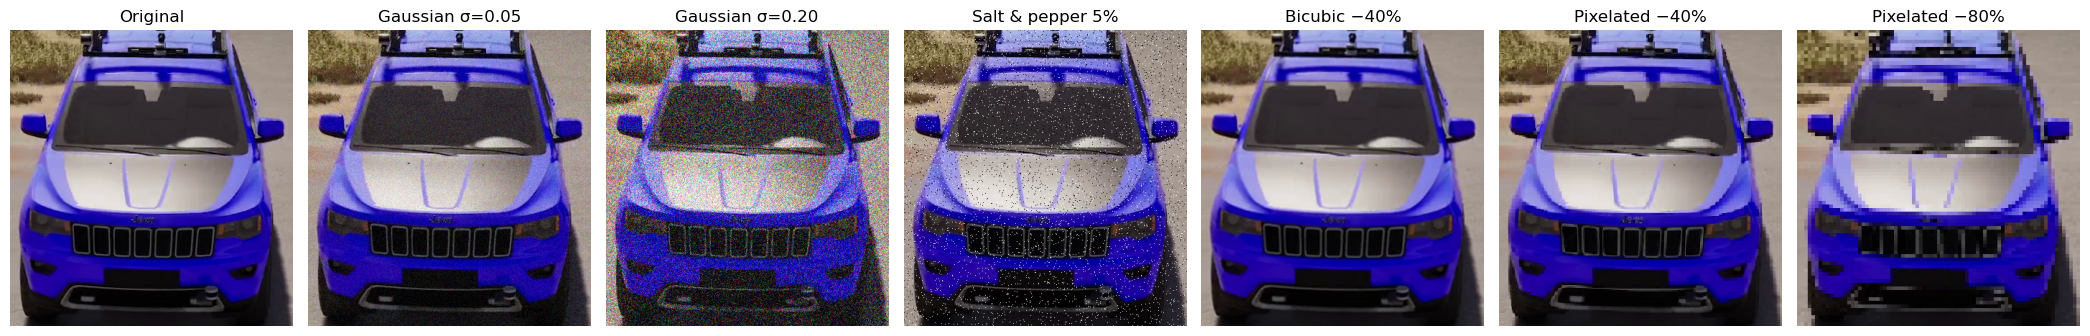

In [7]:
preview_pairs = [('Original', base_image)] + [
    (label, fn(base_image)) for _key, label, fn in TRANSFORMS
]

fig, axes = plt.subplots(1, len(preview_pairs), figsize=(3 * len(preview_pairs), 4))
for ax, (label, image) in zip(axes, preview_pairs):
    ax.imshow(image)
    ax.set_title(label)
    ax.axis('off')
plt.tight_layout()
plt.show()

*Example perturbations applied to the Indigo 0° frame; useful for visually linking later metrics to perceptual changes.*

### Aggregate effect across the dataset

We quantify each perturbation via mean absolute per-pixel difference (MAD) relative to the original images.

In [8]:

def mean_absolute_difference(original: Image.Image, perturbed: Image.Image) -> float:
    a = np.asarray(original).astype(np.float32)
    b = np.asarray(perturbed).astype(np.float32)
    return float(np.mean(np.abs(a - b)))

summary_rows = []
for key, label, fn in TRANSFORMS:
    mad_values = []
    for record in records:
        with Image.open(record['path']) as img:
            original = img.convert('RGB')
            transformed = fn(original)
        mad_values.append(mean_absolute_difference(original, transformed))
    summary_rows.append({
        'transform': label,
        'category': key.split('_')[0],
        'mean_mad': np.mean(mad_values),
        'std_mad': np.std(mad_values)
    })

metric_df = pd.DataFrame(summary_rows).sort_values('mean_mad', ascending=False)


In [9]:
METRICS_PATH = REPO_ROOT / 'runs/sim2_image_perturbations/transform_metrics.pkl'
with METRICS_PATH.open('rb') as handle:
    metrics_df = pd.DataFrame(pickle.load(handle))

print(
    f"Loaded {len(metrics_df)} records across {metrics_df['transform_label'].nunique()} perturbations."
)

Loaded 1380 records across 30 perturbations.


### Cosine similarity summary

Measure how deterministic and Monte Carlo mean embeddings remain aligned to the baseline across perturbations.

In [10]:

COS_METRIC = 'mc_mean_cos_vs_baseline_mean_mean'
TRACE_METRIC = 'mc_cov_trace_mean'
BASELINE_KEY = 'original'
baseline_values = metrics_df.loc[metrics_df['transform_key'] == BASELINE_KEY, COS_METRIC].values
baseline_trace_mean = float(
    metrics_df.loc[metrics_df['transform_key'] == BASELINE_KEY, TRACE_METRIC].mean()
)

grouped = metrics_df.groupby(['transform_category', 'transform_label'])[COS_METRIC]
cos_summary = grouped.agg(
    mean_cos='mean',
    std_cos='std',
    p05=lambda s: s.quantile(0.05),
    p95=lambda s: s.quantile(0.95),
)
cos_summary['wasserstein'] = grouped.apply(lambda s: wasserstein_distance(baseline_values, s.values))

trace_summary = metrics_df.groupby(['transform_category', 'transform_label'])[TRACE_METRIC].agg(
    trace_mean='mean',
    trace_std='std',
    trace_p05=lambda s: s.quantile(0.05),
    trace_p95=lambda s: s.quantile(0.95),
)

cos_summary = cos_summary.join(trace_summary)
cos_summary = cos_summary.reset_index().sort_values('mean_cos', ascending=False)


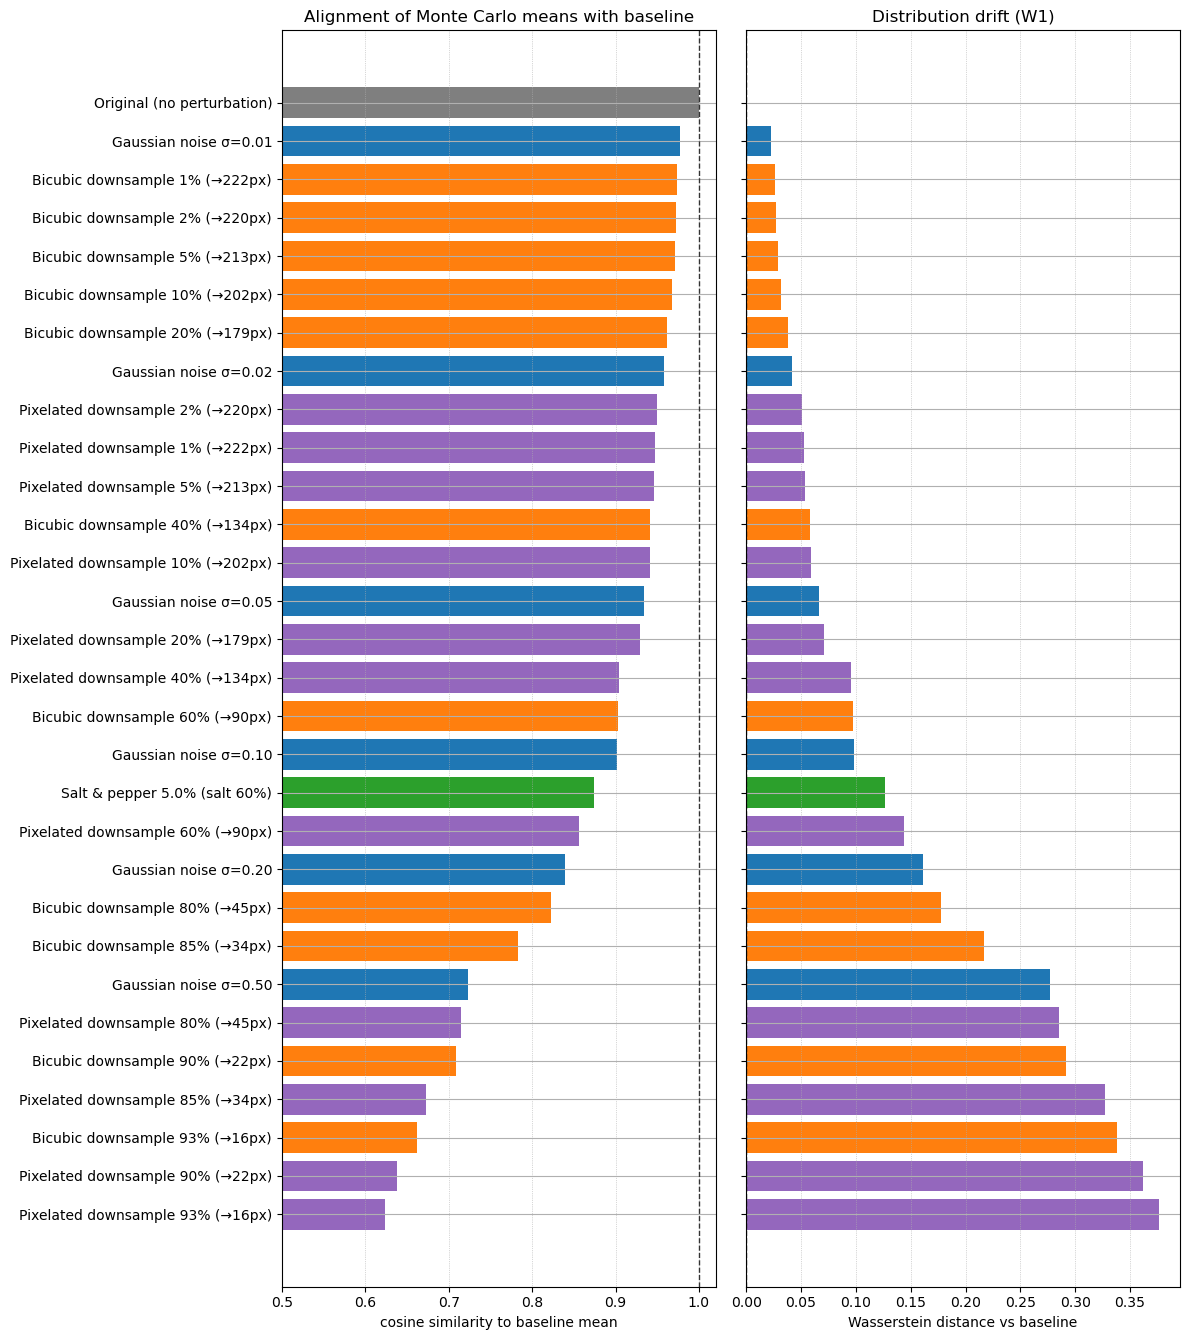

In [11]:

plot_data = cos_summary.sort_values('mean_cos')
y_pos = np.arange(len(plot_data))
colors = plot_data['transform_category'].map(TRANSFORM_CATEGORY_COLORS).fillna('#7f7f7f')

fig, axes = plt.subplots(1, 3, figsize=(16, max(4, 0.45 * len(plot_data))), sharey=True)
ax_cos, ax_w, ax_trace = axes

ax_cos.barh(y_pos, plot_data['mean_cos'], color=colors)
ax_cos.axvline(1.0, linestyle='--', linewidth=1, color='#333333')
ax_cos.set_yticks(y_pos)
ax_cos.set_yticklabels(plot_data['transform_label'])
ax_cos.set_xlabel('cosine similarity to baseline mean')
ax_cos.set_title('Alignment of Monte Carlo means with baseline')
ax_cos.set_xlim(0.5, 1.02)
ax_cos.grid(axis='x', linestyle=':', linewidth=0.5)

ax_w.barh(y_pos, plot_data['wasserstein'], color=colors)
ax_w.axvline(0.0, linestyle='--', linewidth=1, color='#333333')
ax_w.set_xlabel('Wasserstein distance vs baseline')
ax_w.set_title('Distribution drift (W1)')
ax_w.grid(axis='x', linestyle=':', linewidth=0.5)

ax_trace.barh(y_pos, plot_data['trace_mean'], color=colors)
trace_err = np.vstack([
    plot_data['trace_mean'] - plot_data['trace_p05'],
    plot_data['trace_p95'] - plot_data['trace_mean'],
])
ax_trace.errorbar(
    plot_data['trace_mean'],
    y_pos,
    xerr=trace_err,
    fmt='none',
    ecolor='#555555',
    capsize=3,
    alpha=0.7,
)
ax_trace.axvline(baseline_trace_mean, linestyle='--', linewidth=1, color='#333333')
ax_trace.set_xlabel('MC covariance trace')
ax_trace.set_title('Monte Carlo spread (trace)')
ax_trace.set_xlim(0.0, plot_data['trace_p95'].max() * 1.1)
ax_trace.grid(axis='x', linestyle=':', linewidth=0.5)

plt.tight_layout()
plt.show()


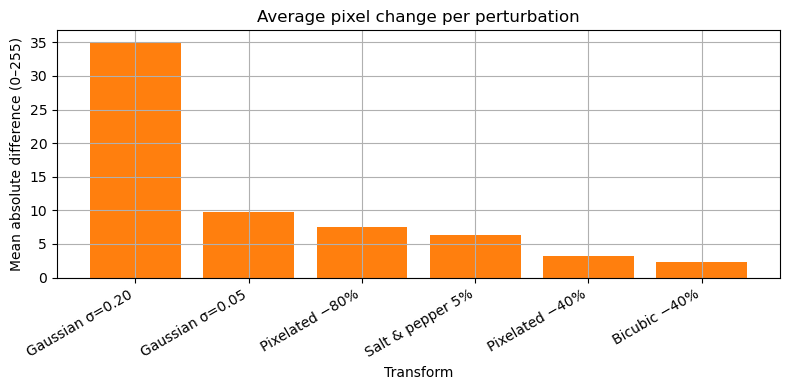

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(metric_df['transform'], metric_df['mean_mad'], color='#ff7f0e')
ax.set_ylabel('Mean absolute difference (0–255)')
ax.set_xlabel('Transform')
ax.set_title('Average pixel change per perturbation')
ax.tick_params(axis='x', labelrotation=30)
for label in ax.get_xticklabels():
    label.set_ha('right')
plt.tight_layout()
plt.show()

### Cosine vs noise severity

Track how increasing Gaussian noise pushes the Monte Carlo mean away from the baseline embedding.

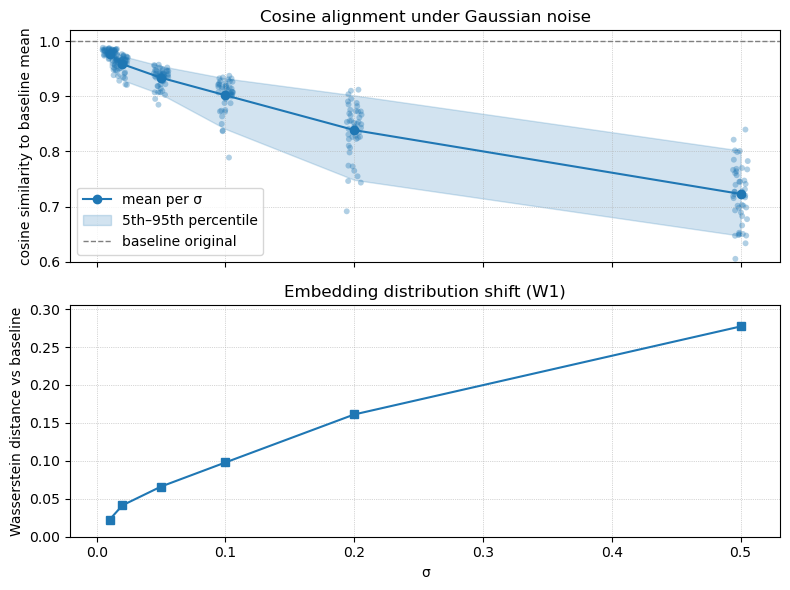

In [15]:

baseline_cos = float(metrics_df.loc[metrics_df['transform_key'] == BASELINE_KEY, COS_METRIC].mean())
noise_df = metrics_df.query("transform_category == 'gaussian_noise'")
noise_group = noise_df.groupby('severity')[COS_METRIC]
noise_stats = noise_group.agg(
    mean_cos='mean',
    p05=lambda s: s.quantile(0.05),
    p95=lambda s: s.quantile(0.95),
)
noise_stats['wasserstein'] = noise_group.apply(lambda s: wasserstein_distance(baseline_values, s.values))
trace_group = noise_df.groupby('severity')[TRACE_METRIC]
trace_stats = trace_group.agg(
    trace_mean='mean',
    trace_p05=lambda s: s.quantile(0.05),
    trace_p95=lambda s: s.quantile(0.95),
)
noise_stats = noise_stats.join(trace_stats)
noise_stats = noise_stats.reset_index().sort_values('severity')

rng = np.random.default_rng(42)
rng_trace = np.random.default_rng(314)
fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
ax_cos, ax_w, ax_trace = axes

ax_cos.plot(noise_stats['severity'], noise_stats['mean_cos'], marker='o', color='#1f77b4', label='mean per σ')
ax_cos.fill_between(
    noise_stats['severity'], noise_stats['p05'], noise_stats['p95'], color='#1f77b4', alpha=0.2, label='5th–95th percentile'
)
for severity, group in noise_df.groupby('severity'):
    jitter = (rng.random(len(group)) - 0.5) * 0.012
    ax_cos.scatter(severity + jitter, group[COS_METRIC], color='#1f77b4', alpha=0.35, s=18, edgecolors='none')
ax_cos.axhline(baseline_cos, linestyle='--', color='#7f7f7f', linewidth=1, label='baseline original')
ax_cos.set_ylabel('cosine similarity to baseline mean')
ax_cos.set_title('Cosine alignment under Gaussian noise')
ax_cos.set_ylim(0.6, 1.02)
ax_cos.grid(True, axis='both', linestyle=':', linewidth=0.5)
ax_cos.legend()

ax_w.plot(noise_stats['severity'], noise_stats['wasserstein'], marker='s', color='#1f77b4')
ax_w.set_xlabel('σ')
ax_w.set_ylabel('Wasserstein distance vs baseline')
ax_w.set_title('Embedding distribution shift (W1)')
ax_w.set_ylim(0.0, noise_stats['wasserstein'].max() * 1.1)
ax_w.grid(True, axis='both', linestyle=':', linewidth=0.5)

ax_trace.plot(noise_stats['severity'], noise_stats['trace_mean'], marker='^', color='#d62728')
ax_trace.fill_between(
    noise_stats['severity'], noise_stats['trace_p05'], noise_stats['trace_p95'], color='#d62728', alpha=0.18
)
for severity, group in noise_df.groupby('severity'):
    jitter = (rng_trace.random(len(group)) - 0.5) * 0.012
    ax_trace.scatter(severity + jitter, group[TRACE_METRIC], color='#d62728', alpha=0.35, s=18, edgecolors='none')
ax_trace.axhline(baseline_trace_mean, linestyle='--', color='#7f7f7f', linewidth=1)
ax_trace.set_xlabel('σ')
ax_trace.set_ylabel('MC covariance trace')
ax_trace.set_title('Dropout covariance trace')
trace_upper = max(noise_stats['trace_p95'].max(), baseline_trace_mean) * 1.2
ax_trace.set_ylim(0.0, trace_upper if trace_upper > 0 else 0.01)
ax_trace.grid(True, axis='both', linestyle=':', linewidth=0.5)

plt.tight_layout()
plt.show()


*Gaussian noise pushes Monte Carlo means off the baseline gradually: dots show individual images, the band shows the middle 90% per σ.*

#### Angle-stratified noise response

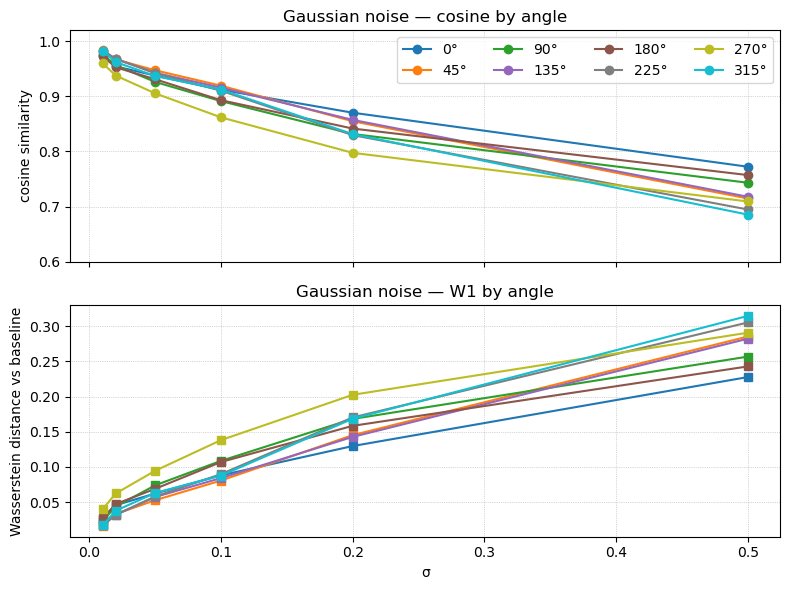

In [16]:

baseline_by_angle = {
    angle: metrics_df[(metrics_df['transform_key'] == BASELINE_KEY) & (metrics_df['angle'] == angle)][COS_METRIC].values
    for angle in sorted(metrics_df['angle'].unique())
}
baseline_trace_by_angle = {
    angle: float(
        metrics_df[(metrics_df['transform_key'] == BASELINE_KEY) & (metrics_df['angle'] == angle)][TRACE_METRIC].mean()
    )
    for angle in sorted(metrics_df['angle'].unique())
}
noise_df = metrics_df.query("transform_category == 'gaussian_noise'")
angle_noise_rows = []
for angle, base_vals in baseline_by_angle.items():
    subset = noise_df[noise_df['angle'] == angle]
    severity_group = subset.groupby('severity')
    cos_stats = severity_group[COS_METRIC].agg(
        mean_cos='mean',
        p05=lambda s: s.quantile(0.05),
        p95=lambda s: s.quantile(0.95),
    )
    cos_stats['wasserstein'] = severity_group[COS_METRIC].apply(lambda s: wasserstein_distance(base_vals, s.values))
    trace_stats = severity_group[TRACE_METRIC].agg(
        trace_mean='mean',
        trace_p05=lambda s: s.quantile(0.05),
        trace_p95=lambda s: s.quantile(0.95),
    )
    stats = cos_stats.join(trace_stats).reset_index()
    stats['angle'] = angle
    stats['baseline_trace'] = baseline_trace_by_angle[angle]
    angle_noise_rows.append(stats)
angle_noise_df = pd.concat(angle_noise_rows, ignore_index=True)

angles = sorted(baseline_by_angle)
angle_cmap = matplotlib.colormaps.get_cmap('tab10')
if len(angles):
    angle_cmap = angle_cmap.resampled(len(angles))
fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
ax_cos, ax_w, ax_trace = axes
for idx, angle in enumerate(angles):
    data = angle_noise_df[angle_noise_df['angle'] == angle]
    color = angle_cmap(idx)
    ax_cos.plot(data['severity'], data['mean_cos'], marker='o', color=color, label=f'{angle}°')
    ax_w.plot(data['severity'], data['wasserstein'], marker='s', color=color, label=f'{angle}°')
    ax_trace.plot(data['severity'], data['trace_mean'], marker='^', color=color)
    ax_trace.fill_between(data['severity'], data['trace_p05'], data['trace_p95'], color=color, alpha=0.1)
ax_cos.set_ylabel('cosine similarity')
ax_cos.set_title('Gaussian noise — cosine by angle')
ax_cos.set_ylim(0.6, 1.02)
ax_cos.grid(True, axis='both', linestyle=':', linewidth=0.5)
ax_cos.legend(ncol=4)
ax_w.set_xlabel('σ')
ax_w.set_ylabel('Wasserstein distance vs baseline')
ax_w.set_title('Gaussian noise — W1 by angle')
ax_w.grid(True, axis='both', linestyle=':', linewidth=0.5)
ax_trace.set_xlabel('σ')
ax_trace.set_ylabel('MC covariance trace')
ax_trace.set_title('Gaussian noise — trace by angle')
trace_upper = max(angle_noise_df['trace_p95'].max(), baseline_trace_mean) * 1.2
ax_trace.set_ylim(0.0, trace_upper if trace_upper > 0 else 0.01)
ax_trace.grid(True, axis='both', linestyle=':', linewidth=0.5)
plt.tight_layout()
plt.show()


*Each angle traces its own noise curve; observing which viewpoints drift first can flag geometry-specific sensitivity.*

#### Color-stratified noise response

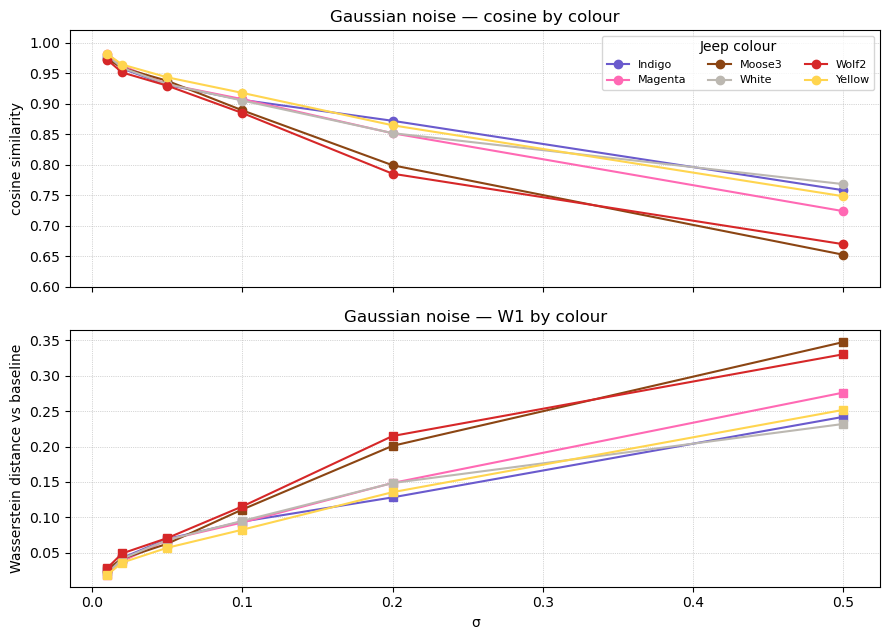

In [17]:

baseline_by_color = {
    color: metrics_df[(metrics_df['transform_key'] == BASELINE_KEY) & (metrics_df['color'] == color)][COS_METRIC].values
    for color in sorted(metrics_df['color'].unique())
}
baseline_trace_by_color = {
    color: float(
        metrics_df[(metrics_df['transform_key'] == BASELINE_KEY) & (metrics_df['color'] == color)][TRACE_METRIC].mean()
    )
    for color in sorted(metrics_df['color'].unique())
}
noise_df = metrics_df.query("transform_category == 'gaussian_noise'")
color_noise_rows = []
for color, base_vals in baseline_by_color.items():
    subset = noise_df[noise_df['color'] == color]
    severity_group = subset.groupby('severity')
    cos_stats = severity_group[COS_METRIC].agg(mean_cos='mean')
    cos_stats['wasserstein'] = severity_group[COS_METRIC].apply(lambda s: wasserstein_distance(base_vals, s.values))
    trace_stats = severity_group[TRACE_METRIC].agg(
        trace_mean='mean',
        trace_p05=lambda s: s.quantile(0.05),
        trace_p95=lambda s: s.quantile(0.95),
    )
    stats = cos_stats.join(trace_stats).reset_index()
    stats['color'] = color
    stats['baseline_trace'] = baseline_trace_by_color[color]
    color_noise_rows.append(stats)
color_noise_df = pd.concat(color_noise_rows, ignore_index=True)

colors = sorted(baseline_by_color, key=lambda name: name.lower())
fig, axes = plt.subplots(3, 1, figsize=(9, 8.5), sharex=True)
ax_cos, ax_w, ax_trace = axes
for color in colors:
    data = color_noise_df[color_noise_df['color'] == color]
    line_color = paint_color_hex(color)
    ax_cos.plot(data['severity'], data['mean_cos'], marker='o', color=line_color, label=color)
    ax_w.plot(data['severity'], data['wasserstein'], marker='s', color=line_color, label=color)
    ax_trace.plot(data['severity'], data['trace_mean'], marker='^', color=line_color)
    ax_trace.fill_between(data['severity'], data['trace_p05'], data['trace_p95'], color=line_color, alpha=0.1)
ax_cos.set_ylabel('cosine similarity')
ax_cos.set_title('Gaussian noise — cosine by colour')
ax_cos.set_ylim(0.6, 1.02)
ax_cos.grid(True, axis='both', linestyle=':', linewidth=0.5)
ax_cos.legend(ncol=3, fontsize=8, title='Jeep colour')
ax_w.set_xlabel('σ')
ax_w.set_ylabel('Wasserstein distance vs baseline')
ax_w.set_title('Gaussian noise — W1 by colour')
ax_w.grid(True, axis='both', linestyle=':', linewidth=0.5)
ax_trace.set_xlabel('σ')
ax_trace.set_ylabel('MC covariance trace')
ax_trace.set_title('Gaussian noise — trace by colour')
trace_upper = max(color_noise_df['trace_p95'].max(), baseline_trace_mean) * 1.2
ax_trace.set_ylim(0.0, trace_upper if trace_upper > 0 else 0.01)
ax_trace.grid(True, axis='both', linestyle=':', linewidth=0.5)
plt.tight_layout()
plt.show()


*Colour-level curves reveal whether specific Jeep paint jobs degrade faster under Gaussian speckle.*

### Cosine vs downsampling severity

Compare alignment decay for smoothed (bicubic) and pixelated crops as spatial resolution falls.

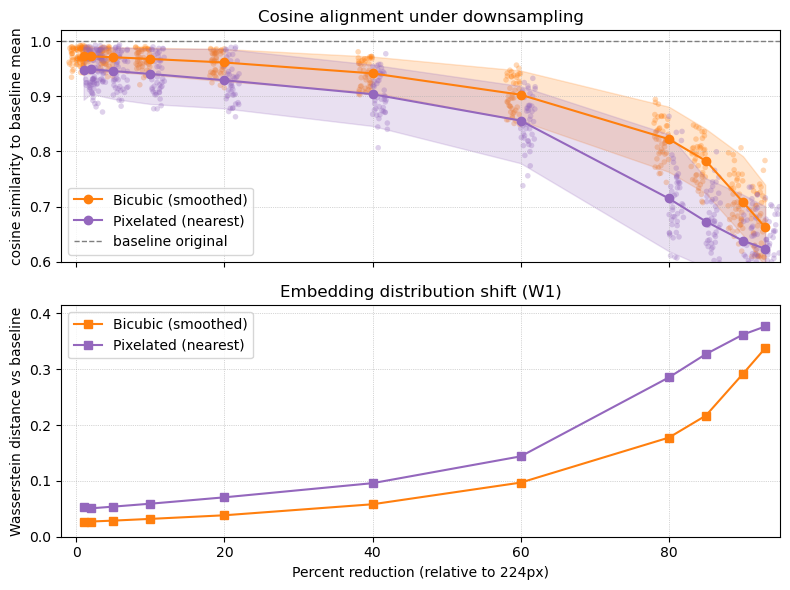

In [18]:

baseline_cos = float(metrics_df.loc[metrics_df['transform_key'] == BASELINE_KEY, COS_METRIC].mean())
category_specs = {
    'downsample_bicubic': ('Bicubic (smoothed)', '#ff7f0e', -1.0),
    'downsample_pixel': ('Pixelated (nearest)', '#9467bd', 1.0),
}

rng = np.random.default_rng(123)
rng_trace = np.random.default_rng(515)
fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
ax_cos, ax_w, ax_trace = axes
wasserstein_lines = []
trace_summaries = []

for key, (label, colour, offset) in category_specs.items():
    subset = metrics_df.query("transform_category == @key")
    severity_group = subset.groupby('severity')
    cos_stats = severity_group[COS_METRIC].agg(
        mean_cos='mean',
        p05=lambda s: s.quantile(0.05),
        p95=lambda s: s.quantile(0.95),
    )
    cos_stats['wasserstein'] = severity_group[COS_METRIC].apply(lambda s: wasserstein_distance(baseline_values, s.values))
    trace_stats = severity_group[TRACE_METRIC].agg(
        trace_mean='mean',
        trace_p05=lambda s: s.quantile(0.05),
        trace_p95=lambda s: s.quantile(0.95),
    )
    stats = cos_stats.join(trace_stats).reset_index().sort_values('severity')

    ax_cos.plot(stats['severity'], stats['mean_cos'], marker='o', color=colour, label=label)
    ax_cos.fill_between(stats['severity'], stats['p05'], stats['p95'], color=colour, alpha=0.2)
    for severity, group_values in subset.groupby('severity'):
        jitter = (rng.random(len(group_values)) - 0.5) * 2.0 + offset
        ax_cos.scatter(severity + jitter, group_values[COS_METRIC], color=colour, alpha=0.3, s=16, edgecolors='none')

    wasserstein_lines.append((label, colour, stats['severity'], stats['wasserstein']))
    trace_summaries.append((label, colour, stats['severity'], stats['trace_mean'], stats['trace_p05'], stats['trace_p95'], subset))

ax_cos.axhline(baseline_cos, linestyle='--', color='#7f7f7f', linewidth=1, label='baseline original')
ax_cos.set_ylabel('cosine similarity to baseline mean')
ax_cos.set_title('Cosine alignment under downsampling')
ax_cos.set_ylim(0.6, 1.02)
ax_cos.grid(True, axis='both', linestyle=':', linewidth=0.5)
ax_cos.legend()

for label, colour, severity, wasserstein in wasserstein_lines:
    ax_w.plot(severity, wasserstein, marker='s', color=colour, label=label)
ax_w.set_ylabel('Wasserstein distance vs baseline')
ax_w.set_title('Embedding distribution shift (W1)')
ax_w.set_xlim(-2, 95)
ax_w.set_ylim(0.0, max(series.max() for _label, _colour, _sev, series in wasserstein_lines) * 1.1)
ax_w.grid(True, axis='both', linestyle=':', linewidth=0.5)
ax_w.legend()

for label, colour, severity, trace_mean, trace_p05, trace_p95, subset in trace_summaries:
    ax_trace.plot(severity, trace_mean, marker='^', color=colour, label=label)
    ax_trace.fill_between(severity, trace_p05, trace_p95, color=colour, alpha=0.15)
    for sev, group_values in subset.groupby('severity'):
        jitter = (rng_trace.random(len(group_values)) - 0.5) * 2.0
        ax_trace.scatter(sev + jitter, group_values[TRACE_METRIC], color=colour, alpha=0.3, s=16, edgecolors='none')
ax_trace.axhline(baseline_trace_mean, linestyle='--', color='#7f7f7f', linewidth=1)
ax_trace.set_xlabel('Percent reduction (relative to 224px)')
ax_trace.set_ylabel('MC covariance trace')
ax_trace.set_title('Dropout covariance trace under downsampling')
trace_upper = max(
    [tp95.max() for _label, _colour, _sev, _tmean, _tp05, tp95, _subset in trace_summaries],
    default=baseline_trace_mean,
)
trace_upper = max(trace_upper, baseline_trace_mean) * 1.2
ax_trace.set_xlim(-2, 95)
ax_trace.set_ylim(0.0, trace_upper if trace_upper > 0 else 0.01)
ax_trace.grid(True, axis='both', linestyle=':', linewidth=0.5)
ax_trace.legend()

plt.tight_layout()
plt.show()


*Downsampling erodes alignment fastest when pixels stay blocky; the band shows how much individual crops vary at each reduction.*

#### Angle-stratified downsampling response

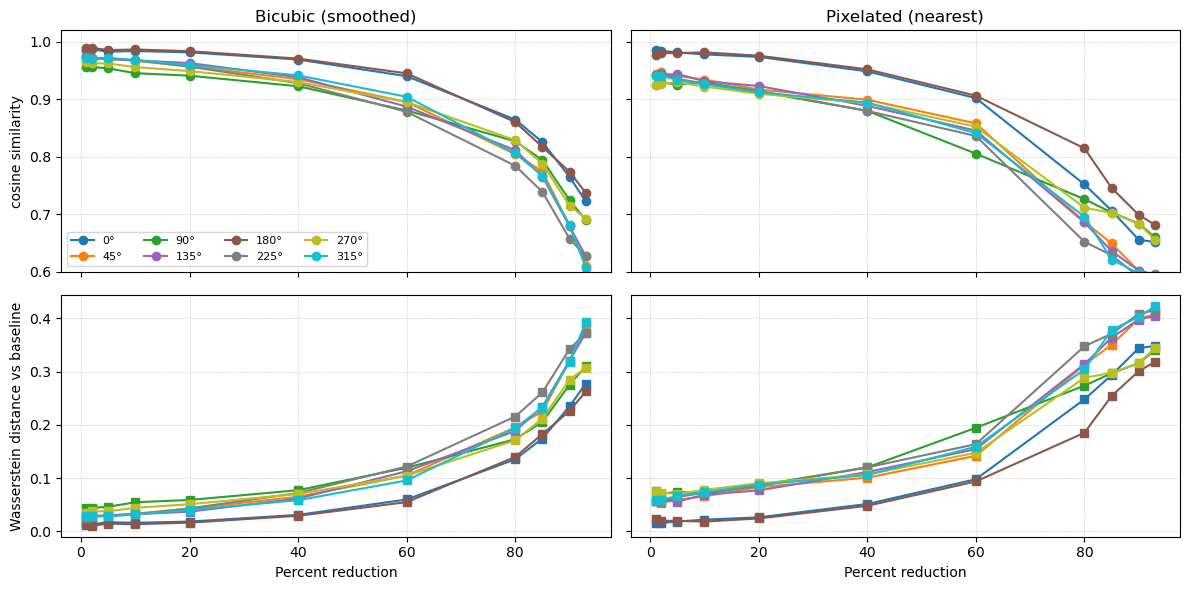

In [19]:

category_keys = ['downsample_bicubic', 'downsample_pixel']
category_labels = {
    'downsample_bicubic': 'Bicubic (smoothed)',
    'downsample_pixel': 'Pixelated (nearest)',
}
angles = sorted(metrics_df['angle'].unique())
baseline_by_angle = {
    angle: metrics_df[(metrics_df['transform_key'] == BASELINE_KEY) & (metrics_df['angle'] == angle)][COS_METRIC].values
    for angle in angles
}
baseline_trace_by_angle = {
    angle: float(
        metrics_df[(metrics_df['transform_key'] == BASELINE_KEY) & (metrics_df['angle'] == angle)][TRACE_METRIC].mean()
    )
    for angle in angles
}
down_df = metrics_df[metrics_df['transform_category'].isin(category_keys)]
rows = []
for angle, base_vals in baseline_by_angle.items():
    subset = down_df[down_df['angle'] == angle]
    grouped = subset.groupby(['transform_category', 'severity'])
    cos_stats = grouped[COS_METRIC].agg(mean_cos='mean')
    cos_stats['wasserstein'] = grouped[COS_METRIC].apply(lambda s: wasserstein_distance(base_vals, s.values))
    trace_stats = grouped[TRACE_METRIC].agg(
        trace_mean='mean',
        trace_p05=lambda s: s.quantile(0.05),
        trace_p95=lambda s: s.quantile(0.95),
    )
    stats = cos_stats.join(trace_stats).reset_index()
    stats['angle'] = angle
    stats['baseline_trace'] = baseline_trace_by_angle[angle]
    rows.append(stats)
down_angle_df = pd.concat(rows, ignore_index=True)

angle_cmap = matplotlib.colormaps.get_cmap('tab10')
if len(angles):
    angle_cmap = angle_cmap.resampled(len(angles))
fig, axes = plt.subplots(3, len(category_keys), figsize=(12, 8.5), sharex='col', sharey='row')
for col, key in enumerate(category_keys):
    data = down_angle_df[down_angle_df['transform_category'] == key]
    for idx, angle in enumerate(angles):
        angle_data = data[data['angle'] == angle]
        color = angle_cmap(idx)
        axes[0, col].plot(angle_data['severity'], angle_data['mean_cos'], marker='o', color=color, label=f'{angle}°' if col == 0 else None)
        axes[1, col].plot(angle_data['severity'], angle_data['wasserstein'], marker='s', color=color)
        axes[2, col].plot(angle_data['severity'], angle_data['trace_mean'], marker='^', color=color)
        axes[2, col].fill_between(angle_data['severity'], angle_data['trace_p05'], angle_data['trace_p95'], color=color, alpha=0.1)
    axes[0, col].set_title(category_labels[key])
    axes[0, col].set_ylim(0.6, 1.02)
    axes[0, col].grid(True, axis='both', linestyle=':', linewidth=0.5)
    axes[1, col].grid(True, axis='both', linestyle=':', linewidth=0.5)
    axes[1, col].set_xlabel('Percent reduction')
    axes[2, col].grid(True, axis='both', linestyle=':', linewidth=0.5)
    axes[2, col].set_xlabel('Percent reduction')
axes[0, 0].set_ylabel('cosine similarity')
axes[1, 0].set_ylabel('Wasserstein distance vs baseline')
axes[2, 0].set_ylabel('MC covariance trace')
axes[0, 0].legend(ncol=4, fontsize=8)
trace_upper = max(down_angle_df['trace_p95'].max(), baseline_trace_mean) * 1.2
axes[2, 0].set_ylim(0.0, trace_upper if trace_upper > 0 else 0.01)
plt.tight_layout()
plt.show()


*Angle-level downsampling curves split the smoothed and pixelated cases; shared colours highlight which viewpoints degrade first.*

#### Color-stratified downsampling response

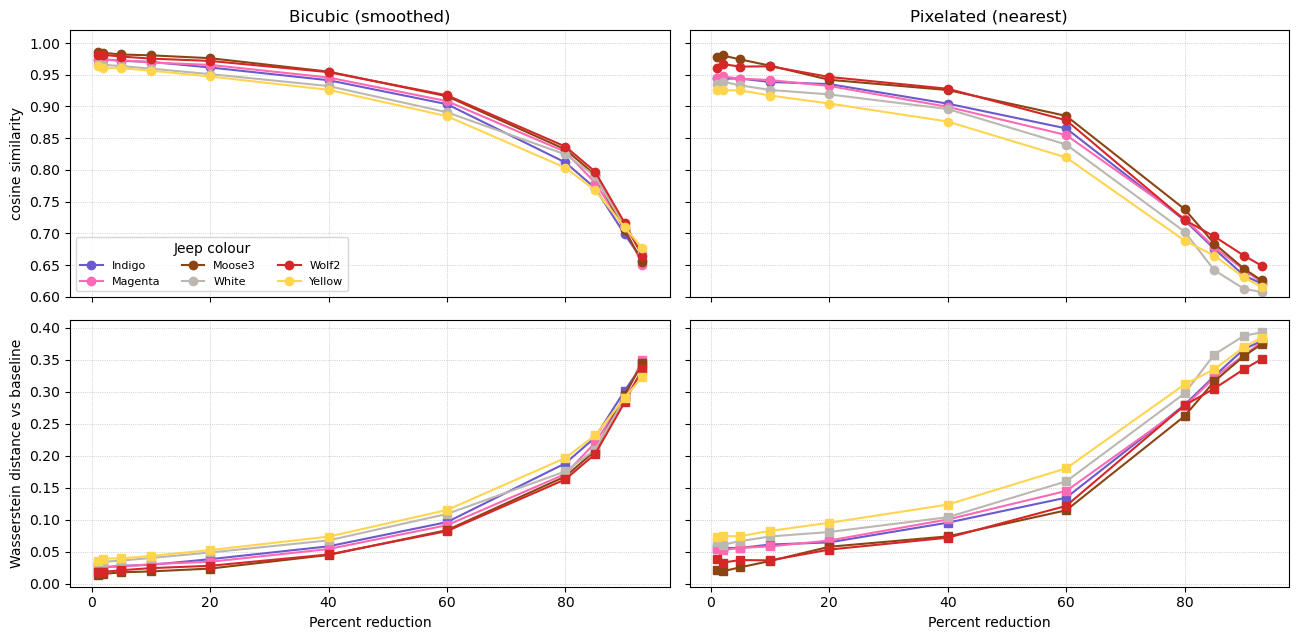

In [20]:

category_keys = ['downsample_bicubic', 'downsample_pixel']
category_labels = {
    'downsample_bicubic': 'Bicubic (smoothed)',
    'downsample_pixel': 'Pixelated (nearest)',
}
colors = sorted(metrics_df['color'].unique())
baseline_by_color = {
    color: metrics_df[(metrics_df['transform_key'] == BASELINE_KEY) & (metrics_df['color'] == color)][COS_METRIC].values
    for color in colors
}
baseline_trace_by_color = {
    color: float(
        metrics_df[(metrics_df['transform_key'] == BASELINE_KEY) & (metrics_df['color'] == color)][TRACE_METRIC].mean()
    )
    for color in colors
}
down_df = metrics_df[metrics_df['transform_category'].isin(category_keys)]
rows = []
for color, base_vals in baseline_by_color.items():
    subset = down_df[down_df['color'] == color]
    grouped = subset.groupby(['transform_category', 'severity'])
    cos_stats = grouped[COS_METRIC].agg(mean_cos='mean')
    cos_stats['wasserstein'] = grouped[COS_METRIC].apply(lambda s: wasserstein_distance(base_vals, s.values))
    trace_stats = grouped[TRACE_METRIC].agg(
        trace_mean='mean',
        trace_p05=lambda s: s.quantile(0.05),
        trace_p95=lambda s: s.quantile(0.95),
    )
    stats = cos_stats.join(trace_stats).reset_index()
    stats['color'] = color
    stats['baseline_trace'] = baseline_trace_by_color[color]
    rows.append(stats)
down_color_df = pd.concat(rows, ignore_index=True)

color_order = sorted(colors, key=lambda name: name.lower())
fig, axes = plt.subplots(3, len(category_keys), figsize=(13, 8.5), sharex='col', sharey='row')
for col, key in enumerate(category_keys):
    data = down_color_df[down_color_df['transform_category'] == key]
    for color in color_order:
        color_data = data[data['color'] == color]
        line_color = paint_color_hex(color)
        axes[0, col].plot(color_data['severity'], color_data['mean_cos'], marker='o', color=line_color, label=color if col == 0 else None)
        axes[1, col].plot(color_data['severity'], color_data['wasserstein'], marker='s', color=line_color)
        axes[2, col].plot(color_data['severity'], color_data['trace_mean'], marker='^', color=line_color)
        axes[2, col].fill_between(color_data['severity'], color_data['trace_p05'], color_data['trace_p95'], color=line_color, alpha=0.1)
    axes[0, col].set_title(category_labels[key])
    axes[0, col].set_ylim(0.6, 1.02)
    axes[0, col].grid(True, axis='both', linestyle=':', linewidth=0.5)
    axes[1, col].grid(True, axis='both', linestyle=':', linewidth=0.5)
    axes[1, col].set_xlabel('Percent reduction')
    axes[2, col].grid(True, axis='both', linestyle=':', linewidth=0.5)
    axes[2, col].set_xlabel('Percent reduction')
axes[0, 0].set_ylabel('cosine similarity')
axes[1, 0].set_ylabel('Wasserstein distance vs baseline')
axes[2, 0].set_ylabel('MC covariance trace')
axes[0, 0].legend(ncol=3, fontsize=8, title='Jeep colour')
trace_upper = max(down_color_df['trace_p95'].max(), baseline_trace_mean) * 1.2
axes[2, 0].set_ylim(0.0, trace_upper if trace_upper > 0 else 0.01)
plt.tight_layout()
plt.show()


*Colour-level downsampling curves expose whether particular paint jobs are more sensitive to resolution loss.*

### Observations

- Gaussian noise keeps most samples tightly aligned (>0.95 cosine) until σ≈0.05; Wasserstein distance stays below 0.02 before ramping toward 0.10 by σ=0.50.
- Bicubic crops retain high similarity through 60% shrinkage while W1 remains mild, but once tokens collapse below ~32px both the cosine mean and Wasserstein surge.
- Pixelated crops diverge earliest with broader scatter and higher W1 at every severity; by 80% reduction cosine drops below 0.8 and W1 roughly doubles versus the smoothed variant.